In [63]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
import numpy as np

In [64]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

x_train, x_test = x_train / 255.0, x_test / 255.0


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


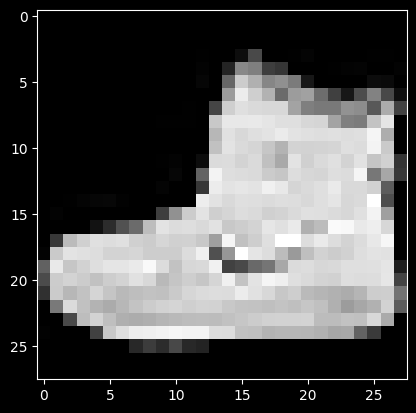

In [65]:
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [66]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
early_stopper = EarlyStopping(
    monitor='val_loss',     # überwacht Validierungsfehler
    patience=4,             # wie viele Epochen warten, bevor abgebrochen wird
    restore_best_weights=True # nimm die besten Gewichte aus der besten Epoche
)

model_history = model.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_test, y_test),
    batch_size=256,
    verbose=1,
    callbacks=[early_stopper]
)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8033 - loss: 0.5769 - val_accuracy: 0.8397 - val_loss: 0.4531
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8587 - loss: 0.4048 - val_accuracy: 0.8507 - val_loss: 0.4216
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8701 - loss: 0.3680 - val_accuracy: 0.8591 - val_loss: 0.3923
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8801 - loss: 0.3353 - val_accuracy: 0.8649 - val_loss: 0.3736
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8864 - loss: 0.3160 - val_accuracy: 0.8744 - val_loss: 0.3541
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8920 - loss: 0.3004 - val_accuracy: 0.8730 - val_loss: 0.3535
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8950 - loss: 0.2884 - val_accuracy: 0.8712 - val_loss: 0.3536
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8997 - loss: 0.2770 - val_accuracy: 0.

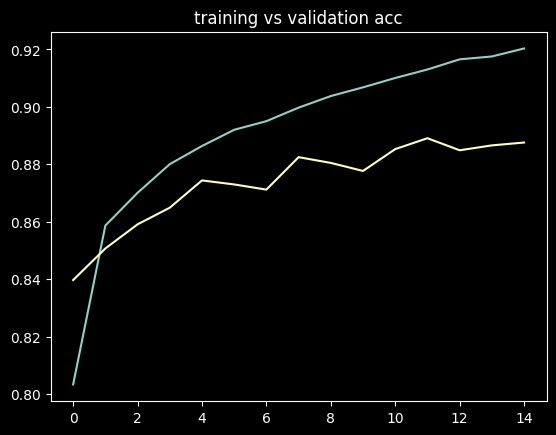

In [68]:
plt.plot(model_history.history["accuracy"])
plt.plot(model_history.history["val_accuracy"])
plt.title("training vs validation acc")
plt.show()

In [73]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(x_test)
y_pred = y_pred.argmax(axis=1)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

cm = confusion_matrix(y_test, y_pred)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step
[[794   1  17  34   4   2 143   0   5   0]
 [  2 973   0  19   3   0   3   0   0   0]
 [ 20   0 767  16 108   0  88   0   1   0]
 [ 13   9   8 915  27   0  23   0   5   0]
 [  0   0  64  39 814   0  80   0   3   0]
 [  0   0   0   1   0 961   0  25   1  12]
 [ 85   0  66  37  49   0 757   0   6   0]
 [  0   0   0   0   0  14   0 973   0  13]
 [  3   0   4   6   3   2   4   4 974   0]
 [  0   0   0   0   0   7   1  54   0 938]]


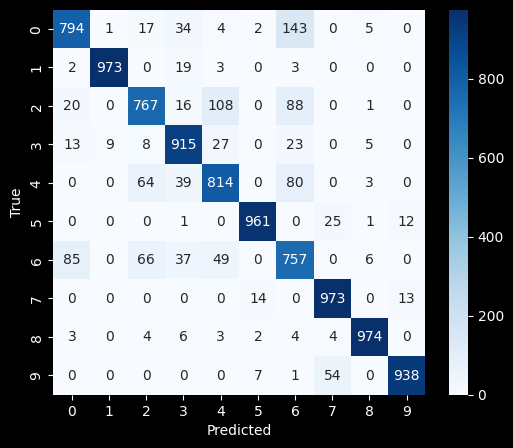

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()